In [7]:
# Notebook mirror of schedule_pmis_module.py — run cells top to bottom after a kernel restart:
# 0 → imports | 1 → AQUILA_PROGRAM_GEOMETRY_LIMITS | 2 → progress helpers | 3 → simulation | then data + run.

# schedule-pmis-module.py
""" 
This module takes as input a schedule (numpy array) and atom arrangement (list of positions)
and outputs the measurement report.
a probability p of measuring an MIS if this schedule is applied. 
"""

import numpy as np
import json
import os
from schedule_pmis_module import *

from graph_MIS_utils import *

In [8]:
L = 3
Rb_a = 2.156411704937441
a = 4e-6
dropout_rate = 0.2
adj, positions = get_lattice_UDG(L, Rb_a, a, dropout_rate)


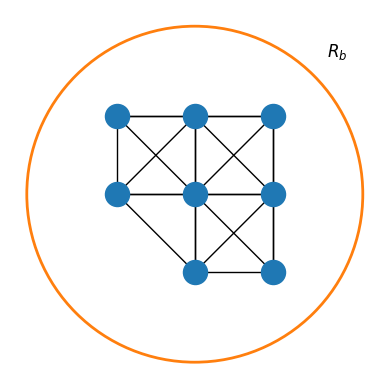

In [9]:
G, nx_positions = construct_graph(positions, Rb_a, a)
fig, ax = plt.subplots()
nx.draw(G, pos=nx_positions, ax=ax)

# Middle node: closest to centroid of the register
coords = np.stack(list(nx_positions.values()))
centroid = coords.mean(axis=0)
node_idx = int(np.argmin(np.linalg.norm(coords - centroid, axis=1)))
center = np.asarray(nx_positions[node_idx])

# lattice size = nearest-neighbor spacing a (meters); use L*a if you mean full linear extent
lattice_size = a
radius = lattice_size * Rb_a
circle = plt.Circle(center, radius, fill=False, edgecolor="tab:orange", linewidth=2)
ax.add_patch(circle)

theta = np.pi / 4
label_xy = center + radius * 1.2 * np.array([np.cos(theta), np.sin(theta)])
ax.text(*label_xy, r"$R_b$", fontsize=12, ha="center", va="center")

# Include full circle and label in view (nx.draw limits ignore the patch)
all_x = np.concatenate(
    [coords[:, 0], [center[0] - radius, center[0] + radius, label_xy[0]]]
)
all_y = np.concatenate(
    [coords[:, 1], [center[1] - radius, center[1] + radius, label_xy[1]]]
)
span = max(all_x.max() - all_x.min(), all_y.max() - all_y.min())
pad = 0.05 * span
ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

ax.set_aspect("equal")
plt.show()

In [4]:
# import importlib
# import schedule_pmis_module
# importlib.reload(schedule_pmis_module)
# from schedule_pmis_module import *

"""
schedule_mode: expect delta only or omega and delta schedules
"""

nshots = 1000
t_max = 4e-6
mode = "omega_delta"

omega_durations = np.array([0. , 0.2, 3.8, 4. ])*1e-6

omega_values = np.array([ 0.        , 13.16087006, 13.16087006,  0.        ])*1e6

delta_durations = np.array([0.        , 0.44444444, 0.88888889, 1.33333333, 1.77777778,
        2.22222222, 2.66666667, 3.11111111, 3.55555556, 4.        ])*1e-6

delta_values = np.array([-64.7426758 , -50.31762928, -39.02921605, -23.62125902,
         -8.99597638,   4.04685322,  17.09031582,  31.90004358,
         49.04959624,  78.60304027])*1e6

schedule = {'OMEGA_DUR': omega_durations,
    'OMEGA_VALS': omega_values,
    'DELTA_DUR': delta_durations,
    'DELTA_VALS': delta_values}

In [5]:
# If this "hangs", the local Braket AHS solver is still working (no progress until `.result()` returns).
# For a quick test, set nshots=10 in the cell above first; 1000 shots × ~18 atoms can take many minutes.

result_full = simulation(
    mode,
    schedule,
    positions,
    L,
    Rb_a,
    a,
    t_max,
    nshots,
    backend="simulator",
    save=True,
)

Starting LocalSimulator (braket_ahs): 8 atoms, 1000 shots.
The local AHS solver runs synchronously: there is no progress output until `.result()` returns. Runtime grows with atom count and shots (often many minutes). Use a small `nshots` (e.g. 5–20) to sanity-check before scaling up.
The elapsed time = 20.81 seconds


In [6]:
analyzing_sim_report(result_full, G, nshots)

MIS probability : 0.6 %


(0.006,
 ['ggrggggr', 'ggrgggrg', 'rgggggrg', 'rggggrgg', 'rgrggggg'],
 [(2, 7), (2, 6), (0, 6), (0, 5), (0, 2)],
 {2: 6, 3: 994})